# Análisis de sesión — §4 del marco teórico

Lee los 6 CSVs de una sesión (`sessions/<id>/`) y genera:

- 5 tablas (calculadas con pandas, mostradas en el notebook)
- 5 gráficos PNG (guardados en la carpeta de sesión)
- `report_<id>.md` — informe completo con tablas markdown + referencias a los plots, listo para copiar al capítulo de Resultados de la tesis

**Uso**: editar `SESSION_DIR` abajo si quieres una sesión específica; por defecto usa la más reciente. Ejecutar todas las celdas (Cell → Run All).

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# === EDITAR si quieres una sesión específica ===
_avail = sorted([p for p in Path('sessions').glob('*') if p.is_dir()])
SESSION_DIR = _avail[-1] if _avail else None
print('Session dir:', SESSION_DIR)
assert SESSION_DIR and SESSION_DIR.exists(), 'No hay sesión disponible.'

REPORT = []
PLOTS_DIR = SESSION_DIR / 'plots'
PLOTS_DIR.mkdir(exist_ok=True)

def load(name, **kw):
    p = SESSION_DIR / name
    if not p.exists():
        print(f'[warn] {name} no existe')
        return pd.DataFrame()
    df = pd.read_csv(p, **kw)
    print(f'  {name}: {len(df)} filas')
    return df

print('CSVs cargados:')
resources = load('resources.csv')
router    = load('router.csv')
latency   = load('backend_latency.csv')
loadtest  = load('loadtest.csv')
events    = load('events.csv')
survey    = load('survey.csv')

for df in (resources, router, latency, loadtest, events):
    if 'ts' in df.columns:
        df['dt'] = pd.to_datetime(df['ts'], unit='s')

def md_table(df, index=True):
    """DataFrame → markdown table string."""
    return df.to_markdown(index=index)

def save_plot(fig, fname, caption=''):
    """Save fig as PNG and return markdown image reference."""
    path = PLOTS_DIR / fname
    fig.savefig(path, dpi=120, bbox_inches='tight')
    plt.show()
    rel = f'plots/{fname}'
    return f'![{caption}]({rel})\n\n*{caption}*'

REPORT.append(f'# Informe de desempeño — sesión `{SESSION_DIR.name}`')
REPORT.append(f'\n*Generado: {datetime.now().isoformat(timespec="seconds")}*\n')

Session dir: sessions/esc3_2026-05-18_1931
CSVs cargados:
  resources.csv: 26 filas
  router.csv: 5 filas
  backend_latency.csv: 1210 filas
[warn] loadtest.csv no existe
  events.csv: 3 filas
  survey.csv: 1 filas


In [2]:
# === Resumen ejecutivo (bullets de portada) ===
summary = []
if not resources.empty:
    host = resources[resources['source'] == 'host']
    if not host.empty:
        summary.append(f'- CPU host: avg **{host["cpu_pct"].mean():.1f}%**, max **{host["cpu_pct"].max():.1f}%**')
        summary.append(f'- RAM host: avg **{host["mem_mb"].mean():.0f} MB**, max **{host["mem_mb"].max():.0f} MB**')
if not router.empty:
    summary.append(f'- Teléfonos asociados máximos: **{int(router["associated_stations"].max())}**')
if not latency.empty:
    summary.append(f'- Latencia backend (todos los endpoints): p50 **{np.percentile(latency["processing_ms"], 50):.1f} ms**, p95 **{np.percentile(latency["processing_ms"], 95):.1f} ms**')
if not loadtest.empty:
    lt = loadtest.copy()
    lt['err_pct'] = lt['errors'] / lt['requests'].replace(0, 1) * 100
    lt['deg'] = ((lt['err_pct'] > 1) | (lt['latency_p95_ms'] > 1000)).astype(int)
    deg = lt[lt['deg'] == 1]
    if not deg.empty:
        summary.append(f'- Capacidad sintética (knee): **<{int(deg.iloc[0]["concurrency"])} concurrentes**')
    else:
        summary.append(f'- Capacidad sintética: sin degradación hasta **{int(lt["concurrency"].max())} concurrentes**')
if not events.empty:
    ev = events.set_index('event')['ts']
    if 'pi_boot' in ev.index and 'first_user' in ev.index:
        delta = (ev['first_user'] - ev['pi_boot']) / 60
        summary.append(f'- Tiempo de montaje (boot → first_user): **{delta:.1f} min**')
if not survey.empty:
    summary.append(f'- Encuesta SUS: **{len(survey)} respuestas**')

summary_md = '## Resumen ejecutivo\n\n' + '\n'.join(summary) + '\n'
print(summary_md)
REPORT.append(summary_md)

## Resumen ejecutivo

- CPU host: avg **4.6%**, max **6.6%**
- RAM host: avg **422 MB**, max **425 MB**
- Teléfonos asociados máximos: **2**
- Latencia backend (todos los endpoints): p50 **9.1 ms**, p95 **19.2 ms**
- Encuesta SUS: **1 respuestas**



TABLA 1


,cpu_pct_mean,cpu_pct_p50,cpu_pct_p95,cpu_pct_max,mem_mb_mean,mem_mb_max,net_rx_kbps_mean,net_tx_kbps_mean
source,,,,,,,,
esc3-attacker,1.1,1.2,1.3,1.3,51.6,51.6,0.8,1.0
esc3-nodered,8.4,7.5,11.7,12.2,104.0,104.7,3.4,42.0
esc3-proxy,0.0,0.0,0.0,0.0,16.0,16.0,0.0,0.0
esc3-target,9.3,10.0,10.7,10.8,32.3,32.3,3.1,26.6
host,4.6,5.4,6.3,6.6,421.6,424.9,146.1,80.2


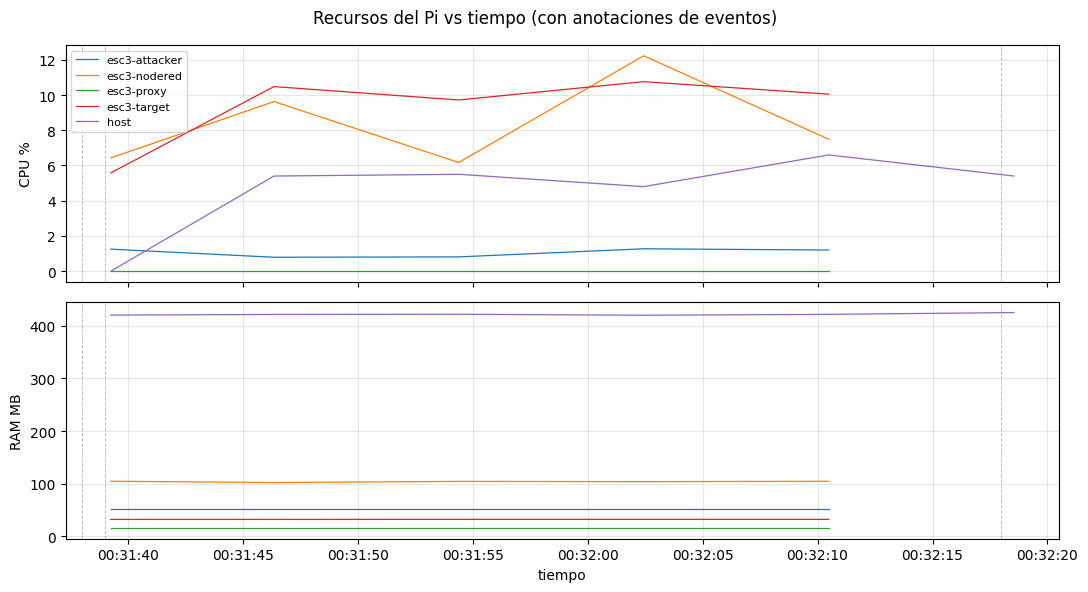

In [3]:
# === TABLA 1 + GRÁFICO 1 — Recursos del Pi ===
REPORT.append('## 1. Recursos del Pi (§4.3)\n')
if not resources.empty:
    t1 = resources.groupby('source').agg(
        cpu_pct_mean=('cpu_pct', 'mean'),
        cpu_pct_p50=('cpu_pct', lambda x: np.percentile(x, 50)),
        cpu_pct_p95=('cpu_pct', lambda x: np.percentile(x, 95)),
        cpu_pct_max=('cpu_pct', 'max'),
        mem_mb_mean=('mem_mb', 'mean'),
        mem_mb_max=('mem_mb', 'max'),
        net_rx_kbps_mean=('net_rx_kbps', 'mean'),
        net_tx_kbps_mean=('net_tx_kbps', 'mean'),
    ).round(1)
    print('TABLA 1'); display(t1)
    REPORT.append('**Tabla 1.** Resumen agregado de recursos por fuente.\n')
    REPORT.append(md_table(t1) + '\n')

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
    for src, g in resources.groupby('source'):
        ax1.plot(g['dt'], g['cpu_pct'], label=src, linewidth=0.9)
        ax2.plot(g['dt'], g['mem_mb'], label=src, linewidth=0.9)
    if not events.empty:
        for _, ev in events.iterrows():
            t = pd.to_datetime(ev['ts'], unit='s')
            for ax in (ax1, ax2):
                ax.axvline(t, color='k', alpha=0.25, linestyle='--', linewidth=0.7)
    ax1.set_ylabel('CPU %'); ax1.legend(loc='upper left', fontsize=8); ax1.grid(alpha=0.3)
    ax2.set_ylabel('RAM MB'); ax2.set_xlabel('tiempo'); ax2.grid(alpha=0.3)
    fig.suptitle('Recursos del Pi vs tiempo (con anotaciones de eventos)')
    plt.tight_layout()
    REPORT.append(save_plot(fig, '01_recursos_vs_tiempo.png',
                            'Figura 1. CPU y RAM del Pi durante la sesión.'))
    REPORT.append('')
else:
    REPORT.append('*Sin datos de recursos en esta sesión.*\n')

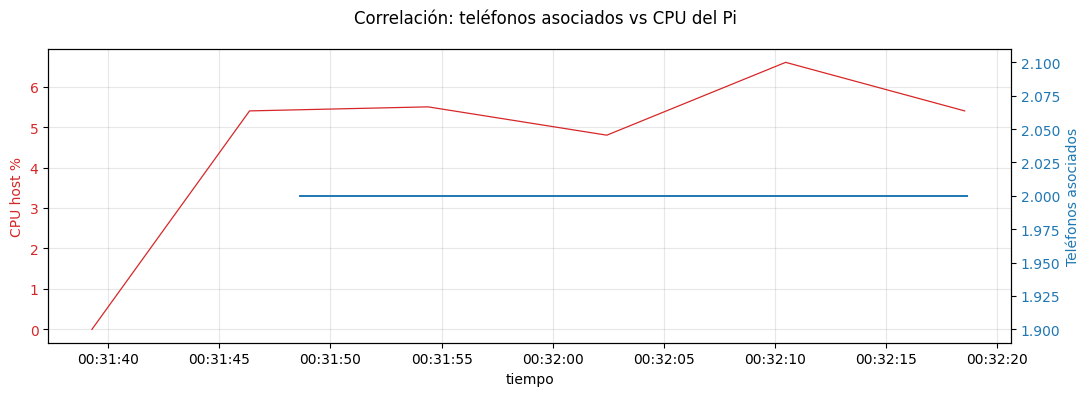

In [4]:
# === GRÁFICO 2 — Teléfonos asociados vs CPU del Pi ===
REPORT.append('## 2. Teléfonos asociados vs CPU del Pi (§4.2 / §4.3)\n')
if not router.empty and not resources.empty:
    host = resources[resources['source'] == 'host']
    if not host.empty and not router.empty:
        fig, ax1 = plt.subplots(figsize=(11, 4))
        ax1.plot(host['dt'], host['cpu_pct'], color='tab:red',
                 label='CPU host %', linewidth=0.9)
        ax1.set_ylabel('CPU host %', color='tab:red')
        ax1.tick_params(axis='y', labelcolor='tab:red')
        ax2 = ax1.twinx()
        ax2.step(router['dt'], router['associated_stations'],
                 color='tab:blue', label='estaciones WiFi', where='post', linewidth=1.4)
        ax2.set_ylabel('Teléfonos asociados', color='tab:blue')
        ax2.tick_params(axis='y', labelcolor='tab:blue')
        ax1.set_xlabel('tiempo'); ax1.grid(alpha=0.3)
        fig.suptitle('Correlación: teléfonos asociados vs CPU del Pi')
        plt.tight_layout()
        REPORT.append(save_plot(fig, '02_telefonos_vs_cpu.png',
                                'Figura 2. Teléfonos asociados al WiFi vs CPU del Pi.'))
        REPORT.append('')
else:
    REPORT.append('*Sin datos de router o recursos.*\n')

TABLA 2


,n,p50_ms,p95_ms,p99_ms,max_ms,error_rate_pct,availability_pct
endpoint,,,,,,,
/api/export_state,1209,9.1,19.2,23.9,51.0,0.0,100.0
/api/survey,1,23.7,23.7,23.7,23.7,0.0,100.0


/tmp/ipykernel_53189/320404675.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=list(t2.index), vert=False, showfliers=False)


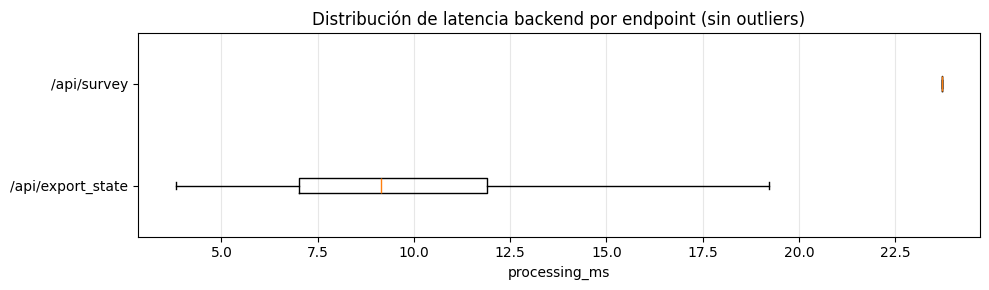

In [5]:
# === TABLA 2 + GRÁFICO 3 — Latencia backend por endpoint ===
REPORT.append('## 3. Latencia backend por endpoint (§4.2)\n')
if not latency.empty:
    t2 = latency.groupby('endpoint').agg(
        n=('processing_ms', 'count'),
        p50_ms=('processing_ms', lambda x: np.percentile(x, 50)),
        p95_ms=('processing_ms', lambda x: np.percentile(x, 95)),
        p99_ms=('processing_ms', lambda x: np.percentile(x, 99)),
        max_ms=('processing_ms', 'max'),
    ).round(1)
    t2['error_rate_pct'] = latency.groupby('endpoint').apply(
        lambda g: 100.0 * ((g['status_code'] >= 500) | (g['status_code'] == 0)).mean(),
        include_groups=False).round(2)
    t2['availability_pct'] = (100 - t2['error_rate_pct']).round(2)
    print('TABLA 2'); display(t2)
    REPORT.append('**Tabla 2.** Latencia backend por endpoint (instrumentada en Node-RED).\n')
    REPORT.append(md_table(t2) + '\n')

    fig, ax = plt.subplots(figsize=(10, max(3, len(t2)*0.5)))
    data = [latency[latency['endpoint'] == ep]['processing_ms'].values for ep in t2.index]
    ax.boxplot(data, labels=list(t2.index), vert=False, showfliers=False)
    ax.set_xlabel('processing_ms')
    ax.set_title('Distribución de latencia backend por endpoint (sin outliers)')
    ax.grid(alpha=0.3, axis='x'); plt.tight_layout()
    REPORT.append(save_plot(fig, '03_latencia_por_endpoint.png',
                            'Figura 3. Latencia backend por endpoint (boxplot).'))
    REPORT.append('')
else:
    REPORT.append('*Sin datos de latencia backend.*\n')

In [6]:
# === TABLA 3 + GRÁFICO 4 — Knee de concurrencia ===
REPORT.append('## 4. Capacidad bajo concurrencia sintética (§4.2)\n')
if not loadtest.empty:
    lt = loadtest.copy()
    lt['error_rate_pct'] = (lt['errors'] / lt['requests'].replace(0, 1) * 100).round(2)
    lt['degraded'] = ((lt['error_rate_pct'] > 1) | (lt['latency_p95_ms'] > 1000)).astype(int)
    t3 = lt[['concurrency', 'requests', 'errors', 'rps',
             'latency_p50_ms', 'latency_p95_ms', 'latency_p99_ms',
             'error_rate_pct', 'degraded']]
    print('TABLA 3'); display(t3)
    deg = lt[lt['degraded'] == 1]
    knee_text = ''
    if not deg.empty:
        knee = int(deg.iloc[0]['concurrency'])
        knee_text = f'\n> **Capacidad máxima funcional: < {knee} concurrentes** (primer escalón degradado).'
    else:
        knee_text = f'\n> No se alcanzó degradación dentro del rango ensayado (máx {int(lt["concurrency"].max())}).'
    REPORT.append('**Tabla 3.** Métricas por escalón de concurrencia (carga sintética asyncio).\n')
    REPORT.append(md_table(t3, index=False) + '\n')
    REPORT.append(knee_text + '\n')

    fig, ax1 = plt.subplots(figsize=(10, 4))
    x = np.arange(len(lt))
    ax1.bar(x - 0.2, lt['rps'], width=0.4, label='RPS', color='tab:green', alpha=0.8)
    ax1.set_ylabel('RPS', color='tab:green'); ax1.tick_params(axis='y', labelcolor='tab:green')
    ax1.set_xticks(x); ax1.set_xticklabels(lt['concurrency'].astype(int))
    ax1.set_xlabel('concurrencia (vusers)')
    ax2 = ax1.twinx()
    ax2.bar(x + 0.2, lt['latency_p95_ms'], width=0.4,
            label='p95 latencia ms', color='tab:red', alpha=0.8)
    ax2.set_ylabel('p95 latencia (ms)', color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')
    if not deg.empty:
        ax1.axvline(deg.index[0], color='k', linestyle='--', alpha=0.4, label='knee')
    ax1.set_title('Curva de capacidad: RPS y p95 vs concurrencia')
    plt.tight_layout()
    REPORT.append(save_plot(fig, '04_curva_knee.png',
                            'Figura 4. Curva de capacidad: RPS y p95 vs concurrencia.'))
    REPORT.append('')
else:
    REPORT.append('*Sin datos de loadtest.*\n')

In [7]:
# === TABLA 4 — Tiempo de montaje (§4.4) ===
REPORT.append('## 5. Tiempo de montaje y plug-and-play (§4.4)\n')
if not events.empty:
    ev = events.set_index('event')['ts']
    boot = ev.get('pi_boot')
    demo_start = ev.get('demo_start')
    first_user = ev.get('first_user')
    rows = []
    if boot is not None and demo_start is not None:
        rows.append(('pi_boot → demo_start', float(demo_start - boot)))
    if demo_start is not None and first_user is not None:
        rows.append(('demo_start → first_user', float(first_user - demo_start)))
    if boot is not None and first_user is not None:
        rows.append(('TOTAL montaje (pi_boot → first_user)', float(first_user - boot)))
    if rows:
        t4 = pd.DataFrame(rows, columns=['fase', 'segundos'])
        t4['minutos'] = (t4['segundos'] / 60).round(2)
        t4['segundos'] = t4['segundos'].round(1)
        print('TABLA 4'); display(t4)
        REPORT.append('**Tabla 4.** Tiempo de montaje (desde encendido del Pi hasta primer usuario).\n')
        REPORT.append(md_table(t4, index=False) + '\n')
    else:
        REPORT.append('*No hay eventos pi_boot / demo_start / first_user registrados.*\n')
    notes = ', '.join(str(n) for n in events['notes'].dropna().tolist() if str(n) != 'nan')
    if notes:
        REPORT.append(f'\n**Notas del operador:** {notes}\n')
else:
    REPORT.append('*Sin eventos registrados.*\n')

TABLA 5


,valor
n_respondientes,1.0
SUS_score_promedio,91.7
SUS_score_p50,91.7
ped1_promedio,5.0
ped2_promedio,5.0


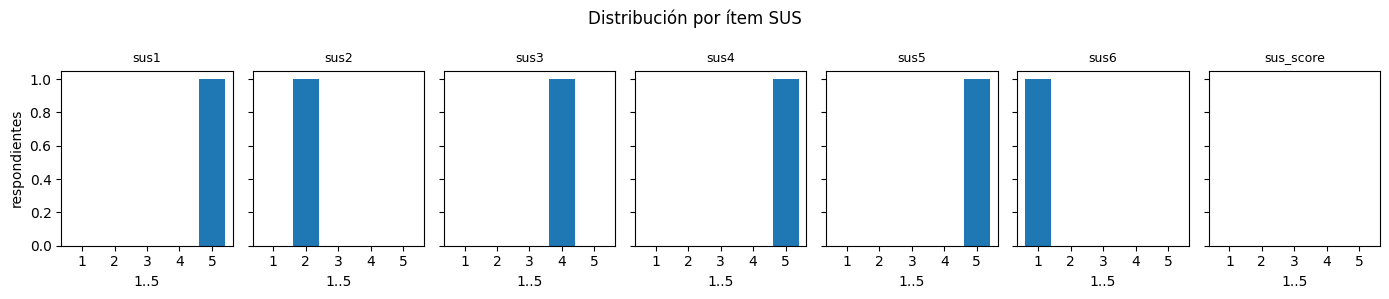

In [8]:
# === TABLA 5 + GRÁFICO 5 — SUS reducido + cualitativas (§4.1) ===
REPORT.append('## 6. Satisfacción de la audiencia (§4.1)\n')

SUS_POSITIVE = {'sus1', 'sus3', 'sus4', 'sus5'}
SUS_NEGATIVE = {'sus2', 'sus6'}

def sus_score(row):
    items = SUS_POSITIVE | SUS_NEGATIVE
    s, n = 0, 0
    for it in items:
        if it in row and pd.notna(row[it]):
            try:
                v = int(row[it])
                s += (v - 1) if it in SUS_POSITIVE else (5 - v)
                n += 1
            except (ValueError, TypeError):
                pass
    return (s / (n * 4)) * 100 if n > 0 else np.nan

if not survey.empty:
    survey = survey.copy()
    survey['sus_score'] = survey.apply(sus_score, axis=1)
    row5 = {
        'n_respondientes': len(survey),
        'SUS_score_promedio': round(survey['sus_score'].mean(), 1) if survey['sus_score'].notna().any() else None,
        'SUS_score_p50': round(survey['sus_score'].median(), 1) if survey['sus_score'].notna().any() else None,
    }
    for col in ('ped1', 'ped2'):
        if col in survey.columns:
            vals = pd.to_numeric(survey[col], errors='coerce')
            if vals.notna().any():
                row5[f'{col}_promedio'] = round(vals.mean(), 2)
    t5 = pd.DataFrame([row5]).T.rename(columns={0: 'valor'})
    print('TABLA 5'); display(t5)
    REPORT.append('**Tabla 5.** Resumen de la encuesta de satisfacción (SUS reducido + pedagógicas).\n')
    REPORT.append(md_table(t5) + '\n')

    sus_items = sorted([c for c in survey.columns if c.startswith('sus')])
    if sus_items:
        fig, axes = plt.subplots(1, len(sus_items),
                                  figsize=(2*len(sus_items), 3), sharey=True)
        if len(sus_items) == 1: axes = [axes]
        for ax, item in zip(axes, sus_items):
            vals = pd.to_numeric(survey[item], errors='coerce').dropna().astype(int)
            counts = vals.value_counts().sort_index().reindex(range(1, 6), fill_value=0)
            ax.bar(counts.index.astype(str), counts.values)
            ax.set_title(item, fontsize=9); ax.set_xlabel('1..5')
        axes[0].set_ylabel('respondientes')
        fig.suptitle('Distribución por ítem SUS')
        plt.tight_layout()
        REPORT.append(save_plot(fig, '05_sus_por_item.png',
                                'Figura 5. Distribución de respuestas por ítem SUS.'))
        REPORT.append('')

    # Comentarios libres
    for col in ('mejoras', 'libre'):
        if col in survey.columns:
            comments = [str(c).strip() for c in survey[col].dropna().tolist() if str(c).strip()]
            if comments:
                REPORT.append(f'\n**Comentarios — `{col}`:**\n')
                for c in comments:
                    REPORT.append(f'> {c}')
                REPORT.append('')
else:
    REPORT.append('*Sin respuestas de encuesta en esta sesión.*\n')

In [9]:
# === Metodología (anexo del informe) ===
REPORT.append('## 7. Metodología (cómo se midió cada cosa)\n')
REPORT.append('| Métrica §4 | Instrumento | Archivo crudo |')
REPORT.append('|---|---|---|')
REPORT.append('| 4.1 Satisfacción (SUS reducido + pedagógicas) | Formulario HTML servido en `/survey.html` con template JSON configurable | `survey.csv` |')
REPORT.append('| 4.2 Latencia backend | `httpNodeMiddleware` en `settings.js` de Node-RED, mide `t_response_finished − t_request_received` por petición | `backend_latency.csv` |')
REPORT.append('| 4.2 Concurrencia (teléfonos reales) | `iw dev <wifi> station dump` cada 5 s por SSH al OpenWrt | `router.csv` |')
REPORT.append('| 4.2 Concurrencia (sintética) | `loadgen.py` con asyncio + httpx, rampa de escalones; reporta p50/p95/p99 y `degraded` (err_rate > 1% o p95 > 1 s) | `loadtest.csv` |')
REPORT.append('| 4.2 Disponibilidad | Derivada: `1 − error_rate` del backend_latency | (calculada) |')
REPORT.append('| 4.3 CPU/RAM/red del Pi | `psutil` + Docker SDK cada 1 s en el Pi; RSS de contenedores leído por `psutil.Process(pid)` por defecto del cgroup memory de RPi OS | `resources.csv` |')
REPORT.append('| 4.3 Ancho de banda red pública | `/proc/net/dev` por SSH al router, delta cada 5 s | `router.csv` |')
REPORT.append('| 4.4 Tiempo de montaje | Eventos manuales del operador (`session.sh log`): `pi_boot`, `demo_start`, `first_user`, `demo_end` | `events.csv` |')
REPORT.append('')
REPORT.append('**Notas de limitaciones:**\n')
REPORT.append('- La latencia backend NO incluye WiFi del teléfono ni render móvil — por diseño y simplicidad metodológica. Es la métrica estándar reportada en benchmarks de servidores.')
REPORT.append('- La capacidad sintética (`loadgen`) corre desde la laptop conectada al LAN, no representa carga real de teléfonos por WiFi.')
REPORT.append('- El RAM del contenedor se mide con `psutil` sobre los PIDs porque el controlador `memory` de cgroup v2 está desactivado por defecto en Raspberry Pi OS.')
REPORT.append('')
REPORT.append(f'**Datos crudos:** `sessions/{SESSION_DIR.name}/*.csv`')

In [10]:
# === CSVs nuevos (item 4-6 del README de mañana) ===
target_health = load('target_health.csv')
esc3_snaps    = load('esc3_stats_snapshot.csv')
audit_users   = load('auditoria_usuarios.csv')
email_capt    = load('email_capturas.csv')
email_env     = load('email_envios.csv')
email_clk     = load('email_clicks.csv')
docker_ev     = load('docker_events.csv')

for df in (target_health, esc3_snaps, audit_users, email_capt, email_env, email_clk, docker_ev):
    if not df.empty and 'ts' in df.columns:
        df['ts'] = pd.to_numeric(df['ts'], errors='coerce')
        df['dt'] = pd.to_datetime(df['ts'], unit='s')


  target_health.csv: 41 filas
  esc3_stats_snapshot.csv: 496 filas
[warn] auditoria_usuarios.csv no existe
[warn] email_capturas.csv no existe
[warn] email_envios.csv no existe
[warn] email_clicks.csv no existe
  docker_events.csv: 0 filas


TABLA 7.1 — disponibilidad por fase


,n,availability_pct,rt_p50_ms,rt_p95_ms,rt_p99_ms
phase,,,,,
idle,41,100.0,20.3,32.5,38.7


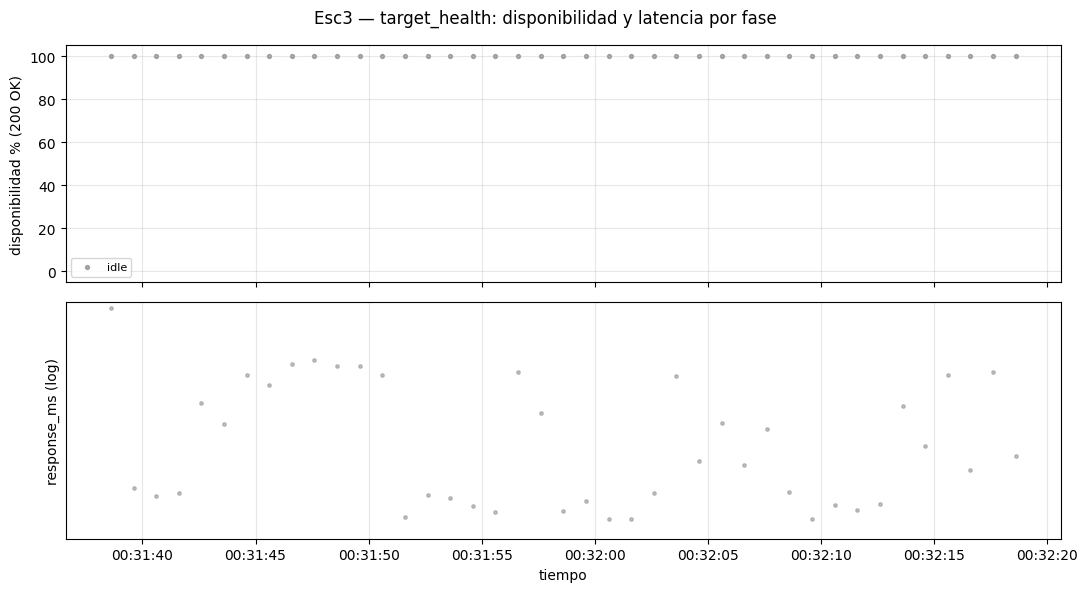

In [11]:
# === Esc3 — Disponibilidad del target durante ataque (target_health.csv) ===
REPORT.append('## 7. Esc3 — Disponibilidad del target Flask\n')
if not target_health.empty:
    th = target_health.copy()
    th['ok'] = (th['status_code'] == 200).astype(int)
    by_phase = th.groupby('phase').agg(
        n=('status_code', 'count'),
        availability_pct=('ok', lambda x: round(x.mean()*100, 2)),
        rt_p50_ms=('response_ms', lambda x: round(np.percentile(x, 50), 1)),
        rt_p95_ms=('response_ms', lambda x: round(np.percentile(x, 95), 1)),
        rt_p99_ms=('response_ms', lambda x: round(np.percentile(x, 99), 1)),
    )
    print('TABLA 7.1 — disponibilidad por fase'); display(by_phase)
    REPORT.append('**Tabla 7.1.** Disponibilidad y latencia del target Flask por fase.\n')
    REPORT.append(md_table(by_phase) + '\n')

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
    colors = {'idle': '#888', 'ataque': '#cc2222', 'protegido': '#1b7a1b', 'unknown': '#bbb'}
    for phase, g in th.groupby('phase'):
        ax1.scatter(g['dt'], g['ok']*100, s=8, color=colors.get(phase, '#bbb'), label=phase, alpha=0.7)
        ax2.scatter(g['dt'], g['response_ms'], s=6, color=colors.get(phase, '#bbb'), alpha=0.5)
    ax1.set_ylabel('disponibilidad % (200 OK)')
    ax1.set_ylim(-5, 105); ax1.legend(loc='lower left', fontsize=8); ax1.grid(alpha=0.3)
    ax2.set_yscale('symlog'); ax2.set_ylabel('response_ms (log)')
    ax2.set_xlabel('tiempo'); ax2.grid(alpha=0.3)
    fig.suptitle('Esc3 — target_health: disponibilidad y latencia por fase')
    plt.tight_layout()
    REPORT.append(save_plot(fig, '07_target_health_esc3.png',
                            'Figura 7. Esc3 — disponibilidad del target Flask por fase (idle/ataque/protegido).'))
    REPORT.append('')
else:
    REPORT.append('*Sin datos de target_health (escenario no era Esc3 o probe no corrió).*\n')


In [12]:
# === GRÁFICO — RX/TX del router (de los 2 plots faltantes mencionados en §4.3) ===
REPORT.append('## 8. RX/TX del router público\n')
if not router.empty and {'rx_kbps', 'tx_kbps'}.issubset(router.columns):
    fig, ax = plt.subplots(figsize=(11, 3.5))
    ax.plot(router['dt'], router['rx_kbps'], label='RX kbps', linewidth=0.9, color='tab:blue')
    ax.plot(router['dt'], router['tx_kbps'], label='TX kbps', linewidth=0.9, color='tab:orange')
    ax.set_ylabel('kbps'); ax.set_xlabel('tiempo'); ax.legend(); ax.grid(alpha=0.3)
    ax.set_title('Tráfico del router (interfaz LAN) — RX y TX')
    plt.tight_layout()
    REPORT.append(save_plot(fig, '08_router_rx_tx.png',
                            'Figura 8. Ancho de banda del router (LAN) RX/TX.'))
    REPORT.append('')
else:
    REPORT.append('*Sin datos de router con columnas rx_kbps/tx_kbps.*\n')


In [13]:
# === Esc1 — Curva de adopción de dispositivos (auditoria_usuarios.csv) ===
REPORT.append('## 9. Esc1 — Curva de adopción de dispositivos\n')
if not audit_users.empty and 'ts' in audit_users.columns:
    au = audit_users.sort_values('ts').copy()
    au['count'] = range(1, len(au) + 1)
    fig, ax = plt.subplots(figsize=(11, 3.5))
    ax.step(au['dt'], au['count'], where='post', linewidth=1.6, color='tab:blue')
    ax.set_ylabel('# dispositivos descubiertos (acumulado)'); ax.set_xlabel('tiempo')
    ax.grid(alpha=0.3); ax.set_title('Esc1 — curva de adopción (descubrimiento de dispositivos)')
    plt.tight_layout()
    REPORT.append(f'Dispositivos totales descubiertos: **{len(au)}**.\n')
    REPORT.append(save_plot(fig, '09_esc1_adopcion.png',
                            'Figura 9. Esc1 — curva acumulada de dispositivos descubiertos.'))
    REPORT.append('')
else:
    REPORT.append('*Sin auditoria_usuarios.csv (escenario distinto o usuarios no registrados).*\n')


In [14]:
# === Esc2 — Funnel de conversión de phishing ===
REPORT.append('## 10. Esc2 — Funnel de conversión\n')
if not email_capt.empty or not email_env.empty or not email_clk.empty:
    funnel = [
        ('capturas (email entregado)', len(email_capt)),
        ('envíos (email enviado por SMTP)', len(email_env)),
        ('clicks (enlace educativo abierto)', len(email_clk)),
    ]
    f_df = pd.DataFrame(funnel, columns=['paso', 'n'])
    if f_df['n'].iloc[0] > 0:
        f_df['conversion_pct'] = (f_df['n'] / f_df['n'].iloc[0] * 100).round(1)
    else:
        f_df['conversion_pct'] = 0.0
    print('TABLA 10 — funnel'); display(f_df)
    REPORT.append('**Tabla 10.** Funnel de conversión Esc2.\n')
    REPORT.append(md_table(f_df, index=False) + '\n')

    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.barh(f_df['paso'], f_df['n'], color=['#cc2222', '#dd8800', '#1b7a1b'])
    for i, (n, pct) in enumerate(zip(f_df['n'], f_df['conversion_pct'])):
        ax.text(n, i, f' {n}  ({pct}%)', va='center', fontsize=9)
    ax.set_xlabel('# personas'); ax.invert_yaxis()
    ax.set_title('Esc2 — funnel de conversión de phishing')
    plt.tight_layout()
    REPORT.append(save_plot(fig, '10_esc2_funnel.png',
                            'Figura 10. Esc2 — funnel de conversión: capturas → envíos → clicks.'))
    REPORT.append('')
else:
    REPORT.append('*Sin datos de email_capturas/envios/clicks (escenario distinto o nadie llenó el form).*\n')


In [15]:
# === Anomalías de contenedores (docker_events.csv) ===
REPORT.append('## 11. Eventos de contenedores durante la sesión\n')
if not docker_ev.empty:
    interesting = docker_ev[docker_ev['action'].isin(['die', 'oom', 'kill', 'restart', 'stop'])].copy()
    if not interesting.empty:
        cols = ['dt', 'action', 'container', 'exit_code', 'signal']
        cols = [c for c in cols if c in interesting.columns]
        display(interesting[cols].head(40))
        REPORT.append(f'**{len(interesting)} eventos** de interés (die/oom/kill/restart/stop) capturados.\n')
        ev_md = interesting[cols].to_markdown(index=False)
        REPORT.append(ev_md + '\n')
    else:
        REPORT.append('*Sin eventos anómalos — ningún contenedor murió ni reinició durante la sesión.*\n')
else:
    REPORT.append('*Sin docker_events.csv.*\n')


In [16]:
# === Análisis estadístico mínimo (Wilcoxon antes/durante/después + CI) ===
REPORT.append('## 12. Análisis estadístico\n')

# 12a. Intervalo de confianza al 95% para SUS (t-Student por n pequeño)
if not survey.empty and 'sus_score' in survey.columns:
    s = survey['sus_score'].dropna()
    n = len(s)
    if n >= 2:
        from scipy import stats as sp
        mean = s.mean(); sem = s.sem(); h = sem * sp.t.ppf(0.975, n-1)
        ci_md = f'SUS score: media **{mean:.1f}** (n={n}), IC95% = **[{mean-h:.1f}, {mean+h:.1f}]** (t-Student).'
        print(ci_md); REPORT.append(ci_md + '\n')
    else:
        REPORT.append(f'*SUS: n={n} respondiente(s), insuficiente para IC.*\n')

# 12b. Wilcoxon antes/durante/después en Esc3 (response_ms del target)
if not target_health.empty:
    th = target_health.copy()
    groups = {p: th[th['phase'] == p]['response_ms'].dropna().values for p in ('idle','ataque','protegido')}
    if all(len(v) >= 5 for k, v in groups.items() if k in ('idle','ataque')):
        from scipy.stats import mannwhitneyu
        u, p = mannwhitneyu(groups['idle'], groups['ataque'], alternative='less')
        msg = f'Esc3: response_ms `idle` vs `ataque` — Mann-Whitney U={u:.0f}, p={p:.2e}.'
        if p < 0.05:
            msg += ' La diferencia es estadísticamente significativa (p<0.05).'
        print(msg); REPORT.append(msg + '\n')
    if all(len(v) >= 5 for k, v in groups.items() if k in ('ataque','protegido')):
        from scipy.stats import mannwhitneyu
        u, p = mannwhitneyu(groups['ataque'], groups['protegido'], alternative='greater')
        msg = f'Esc3: response_ms `ataque` vs `protegido` — Mann-Whitney U={u:.0f}, p={p:.2e}.'
        if p < 0.05:
            msg += ' La protección redujo la latencia significativamente (p<0.05).'
        print(msg); REPORT.append(msg + '\n')

REPORT.append('\n*Nota: con n pequeños (típicos de Casa Abierta) se usa Mann-Whitney (no asume normalidad) y reportamos n explícito en cada tabla.*\n')


In [17]:
# === Glosario de métricas (para el PDF/tesis) ===
REPORT.append('## 13. Glosario de métricas\n')
GLOS = [
    ('p50 (mediana)', 'El 50% de las peticiones se completó en este tiempo o menos.', 'ms', 'Caso típico.'),
    ('p95', 'El 95% de las peticiones se completó en este tiempo o menos.', 'ms', 'Peores casos comunes (1/20). Indicador SLA estándar.'),
    ('p99', 'El 99% de las peticiones se completó en este tiempo o menos.', 'ms', 'Cola larga (1/100). Picos de degradación.'),
    ('RPS', 'Peticiones HTTP por segundo procesadas.', 'req/s', 'Capacidad de trabajo.'),
    ('Knee de concurrencia', 'Primer nivel de concurrencia donde latencia o errores se disparan.', 'concurrencia (int)', 'Techo práctico del servidor.'),
    ('Disponibilidad', '% de peticiones con respuesta HTTP 2xx sobre el total.', '%', 'Confiabilidad durante la demo.'),
    ('SUS score', 'System Usability Scale (Brooke 1996), versión reducida (Lewis & Sauro 2017).', '0–100', '>68 = "sobre el promedio" en estudios estandarizados.'),
    ('NPS pedagógico', 'Adaptación NPS: %promotores − %detractores en intención de recomendar la carrera.', '-100 a +100', 'Intención de recomendación.'),
    ('CPU %', '% uso de CPU promediado sobre todos los cores del Pi.', '% (0-100)', '>80% sostenido = saturación.'),
    ('RAM MB', 'RSS de memoria en uso.', 'MB', 'Pi 3B+ tiene ~900 MB útiles.'),
    ('Click-through rate', '% de los que dieron email y luego clickearon el enlace educativo.', '%', 'Efectividad pedagógica de Esc2.'),
    ('Asociaciones WiFi', 'Dispositivos conectados al SSID en un instante.', 'dispositivos', 'Concurrencia real vs sintética del loadgen.'),
]
glos_df = pd.DataFrame(GLOS, columns=['Métrica', 'Qué mide', 'Unidad', 'Por qué importa'])
REPORT.append(md_table(glos_df, index=False) + '\n')


In [18]:
# === Escribir el informe completo a disco ===
out = SESSION_DIR / f'report_{SESSION_DIR.name}.md'
out.write_text('\n'.join(REPORT) + '\n', encoding='utf-8')
print(f'Informe escrito: {out}')
print(f'Tamaño: {out.stat().st_size:,} bytes')
print(f'Plots PNG: {len(list(PLOTS_DIR.glob("*.png")))} en {PLOTS_DIR}/')
print()
print('=' * 60)
print('Primeras 40 líneas del informe:')
print('=' * 60)
for line in out.read_text().splitlines()[:40]:
    print(line)

Informe escrito: sessions/esc3_2026-05-18_1931/report_esc3_2026-05-18_1931.md
Tamaño: 9,087 bytes
Plots PNG: 5 en sessions/esc3_2026-05-18_1931/plots/

Primeras 40 líneas del informe:
# Informe de desempeño — sesión `esc3_2026-05-18_1931`

*Generado: 2026-05-18T19:32:32*

## Resumen ejecutivo

- CPU host: avg **4.6%**, max **6.6%**
- RAM host: avg **422 MB**, max **425 MB**
- Teléfonos asociados máximos: **2**
- Latencia backend (todos los endpoints): p50 **9.1 ms**, p95 **19.2 ms**
- Encuesta SUS: **1 respuestas**

## 1. Recursos del Pi (§4.3)

**Tabla 1.** Resumen agregado de recursos por fuente.

| source        |   cpu_pct_mean |   cpu_pct_p50 |   cpu_pct_p95 |   cpu_pct_max |   mem_mb_mean |   mem_mb_max |   net_rx_kbps_mean |   net_tx_kbps_mean |
|:--------------|---------------:|--------------:|--------------:|--------------:|--------------:|-------------:|-------------------:|-------------------:|
| esc3-attacker |            1.1 |           1.2 |           1.3 |           1.3 